#Creating Skill Target Diagrams and Taylor Plots


In [1]:
import sys, os
import xarray as xr
import numpy as np
import pandas as pd
import glob
from pathlib import Path
from matplotlib import pyplot as plt
import itertools
import evalhyd
from __future__ import annotations
import math
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

%load_ext autoreload
%autoreload 2

# Keep plots inline
%matplotlib inline

### Process Ensemble Output

In [2]:
def _as_daily_series(da: xr.DataArray) -> pd.Series:
    """
    Resample a DataArray to daily mean and return a pandas.Series (time -> value).
    """
    daily = da.resample(time="1D").mean(skipna=True)
    vals = np.squeeze(daily.values)
    times = pd.to_datetime(daily["time"].values)
    return pd.Series(vals, index=times)

def _align_series(obs: pd.Series, sim: pd.Series) -> Tuple[np.ndarray, np.ndarray]:
    """
    Align on common timestamps; drop NaNs; return (obs_vals, sim_vals).
    Returns empty arrays if no overlap.
    """
    common = obs.index.intersection(sim.index)
    if common.empty:
        return np.array([]), np.array([])
    xo = obs.loc[common].astype(float).to_numpy()
    xs = sim.loc[common].astype(float).to_numpy()
    m = ~np.isnan(xo) & ~np.isnan(xs)
    return xo[m], xs[m]

def _concat_pool(station_series: Dict[str, pd.Series], member: pd.Series) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate aligned (obs, sim) pairs across ALL stations (robust 'many points' pooling).
    """
    xo_all, xs_all = [], []
    for s in station_series.values():
        xo, xs = _align_series(s, member)
        if xo.size:
            xo_all.append(xo)
            xs_all.append(xs)
    if not xo_all:
        return np.array([]), np.array([])
    return np.concatenate(xo_all), np.concatenate(xs_all)


In [3]:
# Cell 1 — Configuration (edit these paths/sources for your run)

CATCHMENT = "tuolumne"
base_dir = "/anvil/projects/x-ees240082/users/dcasson/gpep/"
start_date = '2008-10-01'
end_date = '2018-10-01'

# Observations (CanSWE-style: snw(time, station_id)) and station map
OBS_NETCDF = f"{base_dir}/{CATCHMENT}/snow_data/{CATCHMENT}_NorSWE.nc"
STATION_MAP_CSV = f"{base_dir}/{CATCHMENT}/gis/stations_with_hru_ids.csv"

# Simulation variable name in your SUMMA outputs
VAR_NAME_SIM = "scalarSWE"

# Sources (each dir has .nc files; filenames include 'G####' for the GRU)
ENSEMBLE_SOURCES = [
    {
        "label": "RF Static Dynamic",
        "dir": f"{base_dir}/{CATCHMENT}/ensemble_generation/rf_best_regression_static_dynamic/summa/output/",
        "deterministic": False,
    },
    {
        "label": "CASR",
        "dir": f"{base_dir}/{CATCHMENT}/ensemble_generation/casr_remapped/summa_output",
        "deterministic": True,
    },
    {
        "label": "ERA5",
        "dir": f"{base_dir}/{CATCHMENT}/ensemble_generation/era5_remapped/summa_output",
        "deterministic": True,
    },
]

# GRUs to skip (if any)
EXCLUDE_GRUS = set()

# Cross-test scaling factor f (leave 1.0 unless harmonizing across different tests)
F_SCALE = 1.0

# Outputs
OUTPUT_DIR = Path("./skill_outputs")
OUTPUT_CSV = OUTPUT_DIR / f"skill_metrics_{CATCHMENT}.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Configured.")

Configured.


In [4]:
def filter_stations_by_obs_per_year(ds, var='snw', n=1, start_date='2008-01-01', end_date='2021-12-31', measurement_types=None):
    """
    Filters stations based on a minimum number of valid observations per year for a given variable.
    """
    ds_filtered = ds.sel(time=slice(start_date, end_date))
    if measurement_types is not None:
        type_mask = np.isin(ds_filtered.type_mes, measurement_types)
        ds_filtered = ds_filtered.sel(station_id=ds_filtered.station_id[type_mask])
    valid = ~ds_filtered[var].isnull()
    years = ds_filtered.time.dt.year
    obs_per_year = valid.groupby(xr.DataArray(years, coords={"time": ds_filtered.time}, dims="time").rename("year")).sum(dim="time")
    station_mask = (obs_per_year >= n).all(dim="year")
    return ds_filtered.sel(station_id=ds_filtered.station_id[station_mask])


# Cell 2 — Load observation dataset & station map, pick GRUs
ds_obs_all = xr.open_dataset(OBS_NETCDF, decode_times=True)

station_map = pd.read_csv(STATION_MAP_CSV)

ds_obs = filter_stations_by_obs_per_year(
    ds_obs_all, var="snw", n=0,
    start_date=start_date, end_date=end_date,
    measurement_types=[0]
)

# Ensure station_id is string
station_ids_in_ds = np.asarray(ds_obs["station_id"].values).astype(str)
# Ensure proper merge typing
station_map["station_id"] = station_map["station_id"].astype(str)
# stations with valid obs in period (any non-nan)
valid_obs_mask = ~ds_obs["snw"].isnull().all(dim="time")
valid_station_ids = ds_obs["station_id"].values[valid_obs_mask.values]
# Only use stations in both ds_obs and station_map
stations_in_map = station_map[station_map["station_id"].isin(valid_station_ids)]
grus = stations_in_map["GRU_ID"].unique()

# Top stations by number of obs (could filter by date range if needed)
obs_count = ds_obs["snw"].notnull().sum(dim="time").values
top_indices = np.argsort(-obs_count)[:20]
top_station_ids = ds_obs["station_id"].values[top_indices]


len(ds_obs["time"]), len(ds_obs["station_id"]), len(grus)
print(grus)

[46. 73. 88. 95. 25.]


In [5]:

@dataclass
class PairStats:
    member: str
    n: int
    bias: float
    R: float
    sigma_ratio: float     # σ* = σ_sim / σ_obs
    uRMSE_star: float      # normalized (unit: σ_obs)
    uRMSE_abs: float       # unnormalized (original SWE units)

def _pair_stats(member: str, xo: np.ndarray, xs: np.ndarray) -> Optional[PairStats]:
    """
    Compute bias b, Pearson R, σ*, uRMSE* and uRMSE_abs from aligned arrays.
    Uses Taylor identity: (uRMSE*)^2 = 1 + (σ*)^2 – 2 σ* R
    """
    if xo.size < 2:
        return None

    b  = float(np.nanmean(xs - xo))
    so = float(np.nanstd(xo, ddof=1))
    ss = float(np.nanstd(xs, ddof=1))
    if not np.isfinite(so) or so == 0.0:
        return None

    # Pearson R
    if np.nanstd(xo) == 0 or np.nanstd(xs) == 0:
        R = np.nan
    else:
        R = float(np.corrcoef(xo, xs)[0, 1])

    sigma_ratio = ss / so if np.isfinite(ss) else np.nan
    if np.isfinite(R) and np.isfinite(sigma_ratio) and sigma_ratio > 0:
        u2 = 1.0 + sigma_ratio**2 - 2.0 * sigma_ratio * R
        uRMSE_star = float(np.sqrt(max(0.0, u2)))
    else:
        uRMSE_star = np.nan

    uRMSE_abs = uRMSE_star * so if np.isfinite(uRMSE_star) else np.nan
    return PairStats(member, xo.size, b, R, sigma_ratio, uRMSE_star, uRMSE_abs)

def _taylor_skill_score(R: float, sigma_ratio: float) -> float:
    """
    Classic Taylor skill score ∈ [0, 1]:  S_Taylor = 2(1+R) / (σ* + 1/σ*)^2
    """
    if not (np.isfinite(R) and np.isfinite(sigma_ratio) and sigma_ratio > 0):
        return np.nan
    return 2.0 * (1.0 + R) / ((sigma_ratio + 1.0 / sigma_ratio) ** 2)
# --- add this helper just above _skills_from_pairs ---
def _spattern_from_pair(p: PairStats, f: float) -> float:
    s_taylor = _taylor_skill_score(p.R, p.sigma_ratio)
    return f * (1.0 - s_taylor)

# --- replace the whole _skills_from_pairs with this version ---
def _skills_from_pairs(pairs: List[PairStats],
                       f: float,
                       u_abs_max: Optional[float] = None,
                       s_pat_max: Optional[float] = None) -> pd.DataFrame:
    """
    Build S_pattern, S_bias, S_total for each member (lower = better).

    If u_abs_max and s_pat_max are provided, use those *shared* maxima (e.g., across all sources for a GRU).
    Otherwise fall back to computing maxima from the given 'pairs' only (backwards compatible).
    """
    if not pairs:
        return pd.DataFrame()

    # S_pattern per pair
    s_pat = {p.member: _spattern_from_pair(p, f) for p in pairs}

    # Establish normalization constants
    u_abs_vals = [p.uRMSE_abs for p in pairs]
    local_u_abs_max = np.nanmax(u_abs_vals) if np.isfinite(np.nanmax(u_abs_vals)) else np.nan
    local_s_pat_max = np.nanmax([abs(v) for v in s_pat.values()]) if s_pat else np.nan

    U = u_abs_max if (u_abs_max is not None and np.isfinite(u_abs_max)) else local_u_abs_max
    SPMAX = s_pat_max if (s_pat_max is not None and np.isfinite(s_pat_max)) else local_s_pat_max

    rows = []
    for p in pairs:
        sp = s_pat[p.member]
        if np.isfinite(U) and U > 0 and np.isfinite(SPMAX):
            sb_mag = f * (abs(p.bias) / U) * SPMAX
            sb = np.sign(p.bias) * sb_mag
        else:
            sb = np.nan
        st = math.sqrt(sp**2 + sb**2) if (np.isfinite(sp) and np.isfinite(sb)) else np.nan

        rows.append({
            "member": p.member, "N": p.n, "bias": p.bias, "R": p.R,
            "sigma_ratio": p.sigma_ratio, "uRMSE_star": p.uRMSE_star, "uRMSE_abs": p.uRMSE_abs,
            "S_pattern": sp, "S_bias": sb, "S_total": st
        })
    return pd.DataFrame(rows).sort_values("S_total").reset_index(drop=True)

In [6]:
def load_station_series_by_gru(ds_obs: xr.Dataset,
                               station_map: pd.DataFrame,
                               gru_id: int) -> Dict[str, pd.Series]:
    """
    Return {station_name: Series} for stations in GRU, using var 'snw' from CanSWE file.
    """
    ids = station_map.loc[station_map["GRU_ID"] == gru_id, "station_id"].astype(str).values
    nc_station_ids = [str(s) for s in ds_obs["station_id"].values]
    station_names  = [str(s) for s in ds_obs["station_name"].values]
    indices = [i for i, sid in enumerate(nc_station_ids) if sid in ids]

    out: Dict[str, pd.Series] = {}
    for i in indices:
        da = ds_obs["snw"].isel(station_id=i)  # (time,)
        out[station_names[i]] = _as_daily_series(da)
    return out

def files_for_source_and_gru(src: dict, gru: int) -> List[str]:
    src_dir = Path(src["dir"])
    g = int(gru)
    patterns = [f"G{g:04d}-{g:04d}", f"G{g:03d}-{g:03d}"]
    return sorted(
        str(p) for p in src_dir.glob("*.nc")
        if any(pat in p.name for pat in patterns)
    )

def build_members_from_spec(files: List[str], label: str, deterministic: bool, var_name_sim: str) -> Dict[str, pd.Series]:
    """
    Build {member_name: Series}:
      - deterministic → 1 member (label '(...det)')
      - ensemble     → 1 member per file (label 'm1', 'm2', …)
    """
    members: Dict[str, pd.Series] = {}
    if deterministic:
        ds = xr.open_dataset(files[0], decode_times=True)
        members[f"{label} (det)"] = _as_daily_series(ds[var_name_sim])
    else:
        for k, path in enumerate(files, start=1):
            ds = xr.open_dataset(path, decode_times=True)
            members[f"{label} m{k}"] = _as_daily_series(ds[var_name_sim])
    return members

In [7]:

all_rows: List[pd.DataFrame] = []

for gru in grus:
    print(f"\nGRU {gru}")
    # Load obs for this GRU
    station_series = load_station_series_by_gru(ds_obs, station_map, gru)
    if not station_series:
        print("  (no stations for this GRU; skipping)")
        continue

    # 1) Gather all pairs across all sources for this GRU
    pairs_by_source: Dict[str, List[PairStats]] = {}
    for src in ENSEMBLE_SOURCES:
        files = files_for_source_and_gru(src, gru)
        if not files:
            print(f"  {src['label']}: no files for this GRU")
            continue

        members = build_members_from_spec(files, src["label"], src["deterministic"], VAR_NAME_SIM)

        pairs: List[PairStats] = []
        for name, ser in members.items():
            xo, xs = _concat_pool(station_series, ser)  # pooled over stations in this GRU
            ps = _pair_stats(name, xo, xs)
            if ps:
                pairs.append(ps)

        if pairs:
            pairs_by_source[src["label"]] = pairs
            print(f"  {src['label']}: {len(pairs)} members")

    if not pairs_by_source:
        print("  (no valid pairs across sources; skipping GRU)")
        continue

    # 2) Compute shared maxima across *all* products for this GRU
    all_pairs = [p for plist in pairs_by_source.values() for p in plist]
    # uRMSE_abs max in SWE units
    u_abs_vals = [p.uRMSE_abs for p in all_pairs if np.isfinite(p.uRMSE_abs)]
    if not u_abs_vals:
        print("  (no finite uRMSE_abs values; skipping GRU)")
        continue
    shared_u_abs_max = float(np.nanmax(u_abs_vals))

    # |S_pattern|_max (requires computing S_pattern for each pair)
    s_pat_vals = [abs(_spattern_from_pair(p, F_SCALE)) for p in all_pairs]
    shared_s_pat_max = float(np.nanmax(s_pat_vals)) if s_pat_vals else np.nan
    if not np.isfinite(shared_s_pat_max):
        print("  (no finite S_pattern values; skipping GRU)")
        continue

    # 3) Build per-source DataFrames using shared normalization
    for label, pairs in pairs_by_source.items():
        df = _skills_from_pairs(
            pairs,
            f=F_SCALE,
            u_abs_max=shared_u_abs_max,
            s_pat_max=shared_s_pat_max
        )
        if df.empty:
            continue
        df.insert(0, "Source", label)
        df.insert(1, "GRU_ID", gru)
        all_rows.append(df)

# 4) Save
if all_rows:
    out_df = pd.concat(all_rows, ignore_index=True)
    out_df.to_csv(OUTPUT_CSV, index=False)
    display(out_df.head(10))
    print(f"\nSaved metrics to {OUTPUT_CSV.resolve()}")
else:
    print("No results produced — check paths, GRU filters, and file patterns.")


GRU 46.0


  RF Static Dynamic: 50 members
  CASR: 1 members
  ERA5: 1 members

GRU 73.0
  RF Static Dynamic: 50 members
  CASR: 1 members
  ERA5: 1 members

GRU 88.0
  RF Static Dynamic: 50 members
  CASR: 1 members
  ERA5: 1 members

GRU 95.0
  RF Static Dynamic: 50 members
  CASR: 1 members
  ERA5: 1 members

GRU 25.0
  RF Static Dynamic: 50 members
  CASR: 1 members
  ERA5: 1 members


,Source,GRU_ID,member,N,bias,R,sigma_ratio,uRMSE_star,uRMSE_abs,S_pattern,S_bias,S_total
0,RF Static Dynamic,46.0,RF Static Dynamic m4,20,-8.180115,0.963731,1.034890,0.276199,121.199670,0.019288,-0.005841,0.020153
1,RF Static Dynamic,46.0,RF Static Dynamic m5,20,21.427753,0.974848,1.077397,0.245333,107.655152,0.018043,0.015300,0.023657
2,RF Static Dynamic,46.0,RF Static Dynamic m2,20,16.235119,0.959953,1.063218,0.298586,131.023381,0.023697,0.011593,0.026380
3,RF Static Dynamic,46.0,RF Static Dynamic m12,20,2.568974,0.962492,1.099733,0.304047,133.419598,0.027569,0.001834,0.027630
4,RF Static Dynamic,46.0,RF Static Dynamic m36,20,16.706156,0.964310,1.100100,0.297563,130.574695,0.026730,0.011929,0.029271
5,RF Static Dynamic,46.0,RF Static Dynamic m3,20,17.225296,0.962949,1.121964,0.313074,137.380898,0.031410,0.012300,0.033732
6,RF Static Dynamic,46.0,RF Static Dynamic m47,20,-8.814410,0.942161,1.070925,0.359043,157.552727,0.033465,-0.006294,0.034051
7,RF Static Dynamic,46.0,RF Static Dynamic m31,20,-25.523839,0.971639,1.141966,0.291427,127.882163,0.031352,-0.018225,0.036264
8,RF Static Dynamic,46.0,RF Static Dynamic m30,20,-14.854515,0.964868,1.143756,0.317852,139.477609,0.035079,-0.010607,0.036648
9,RF Static Dynamic,46.0,RF Static Dynamic m10,20,-1.204259,0.922991,0.973294,0.388096,170.301404,0.039209,-0.000860,0.039218



Saved metrics to /home/x-dcasson/GitRepos/gpep_to_summa_snakemake/workflow/notebooks/visualization/skill_outputs/skill_metrics_tuolumne.csv


<>:317: SyntaxWarning: invalid escape sequence '\c'
<>:317: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_4125931/1394896424.py:317: SyntaxWarning: invalid escape sequence '\c'
  "Correlation (R, $0^\circ$)",


Output to skill_outputs/combined_figures/target_heatmap_PLUS_taylor_3x2.pdf


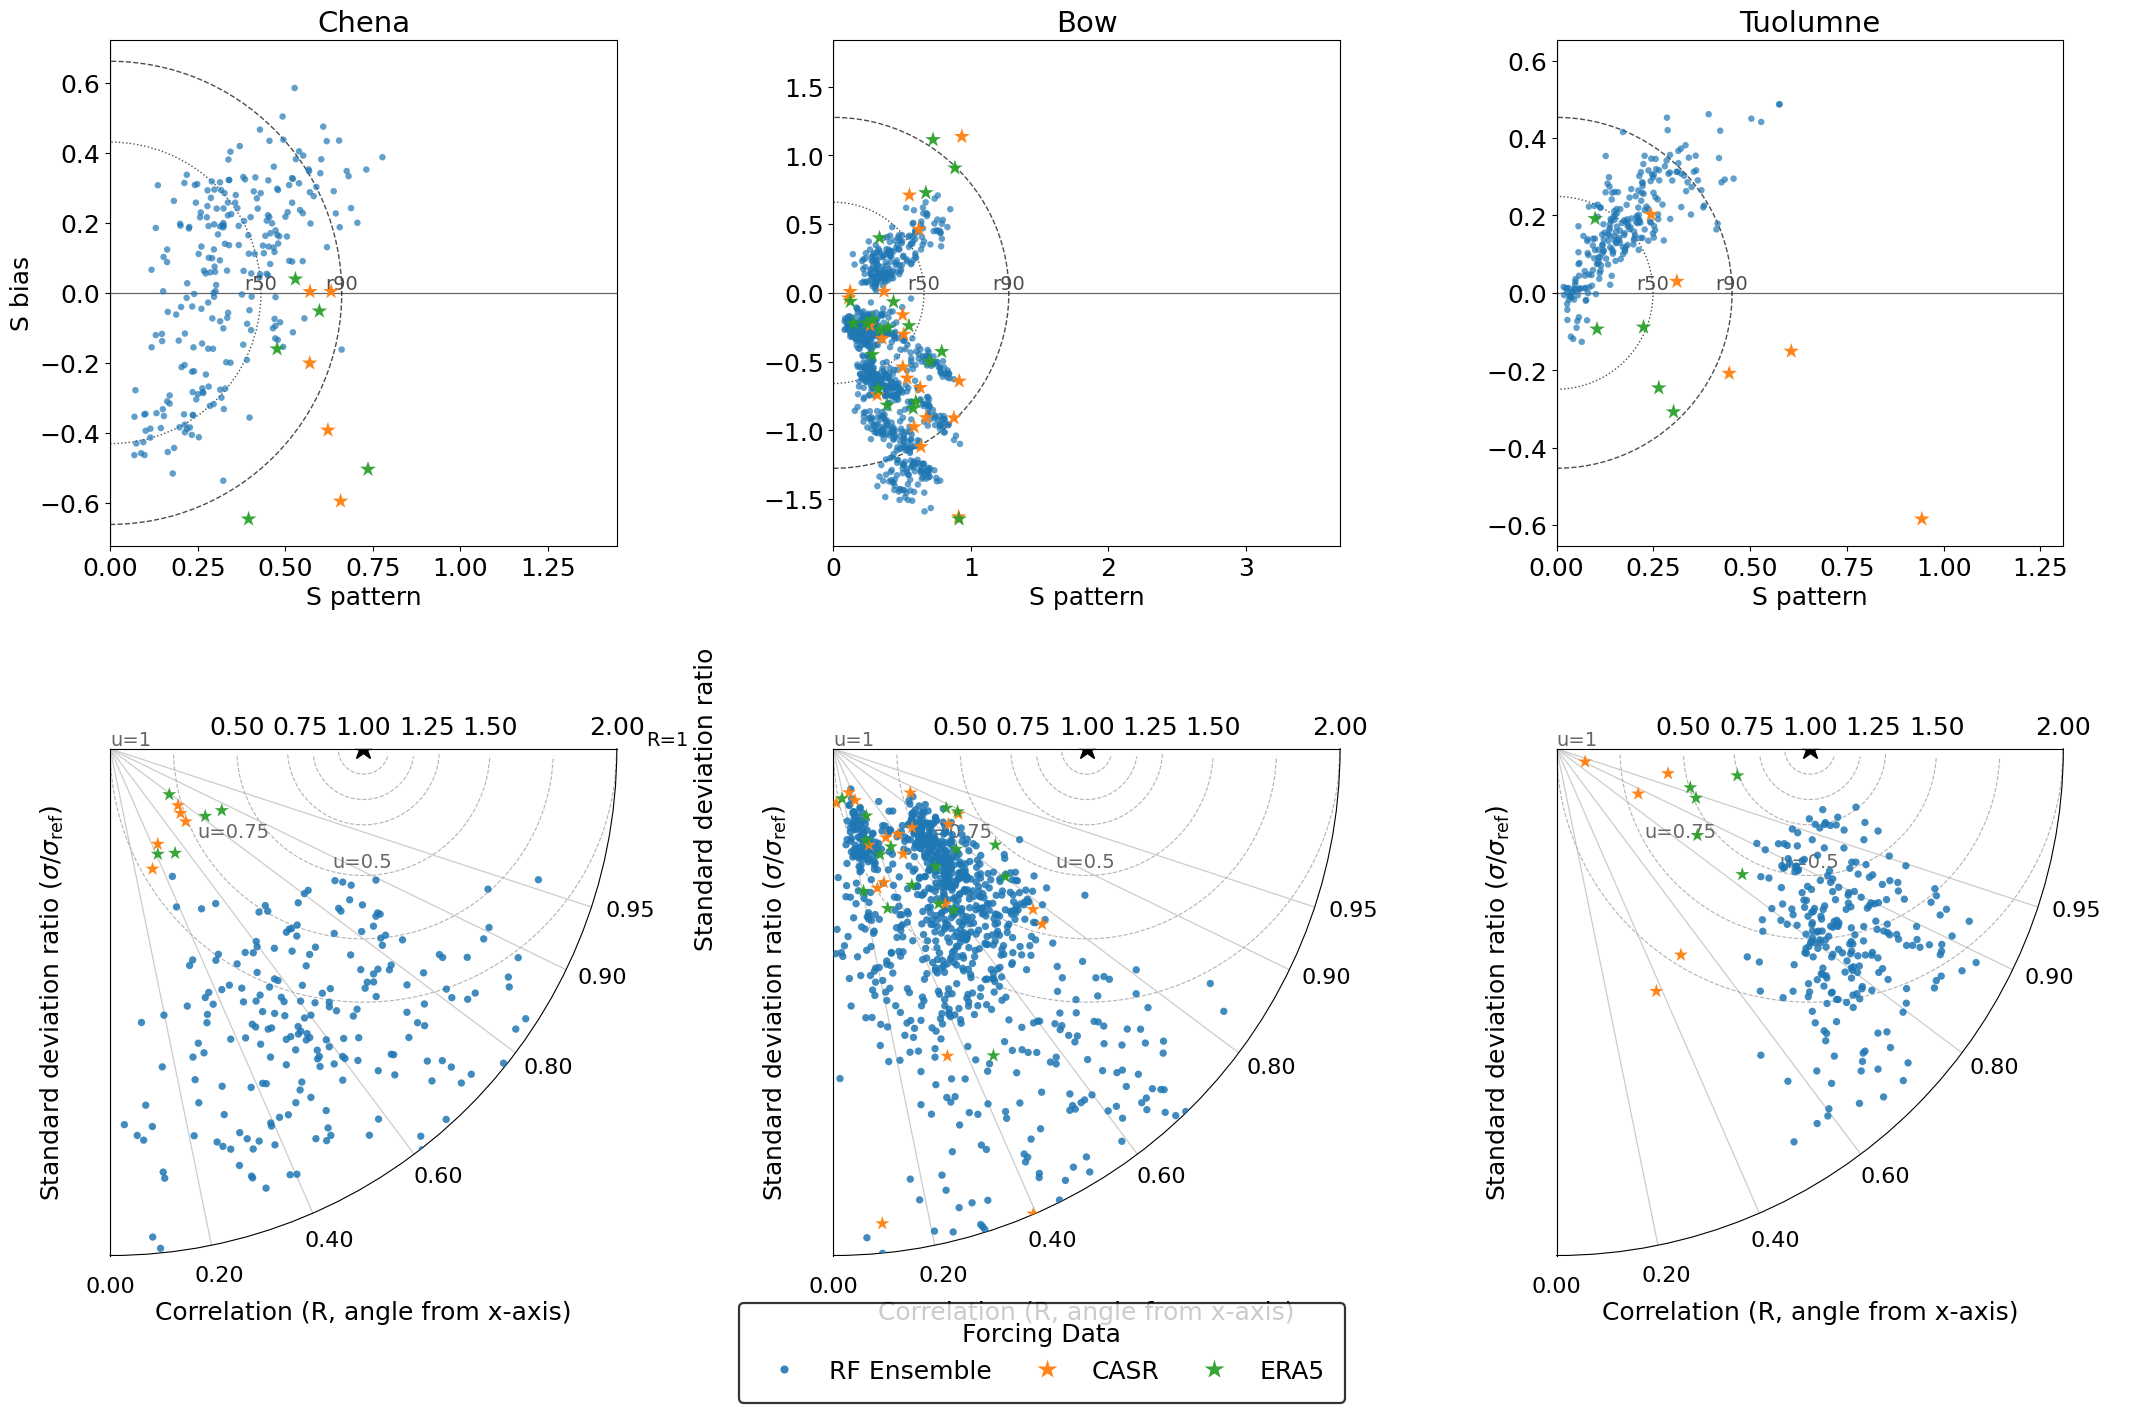

Saved /home/x-dcasson/GitRepos/gpep_to_summa_snakemake/workflow/notebooks/visualization/skill_outputs/combined_figures/target_heatmap_PLUS_taylor_3x2.pdf


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from numpy.linalg import LinAlgError

# ---------------- config ----------------
CATCHMENTS      = ["chena","bow", "tuolumne"]
CSV_PATHS       = {cat: Path(f"./skill_outputs/skill_metrics_{cat}.csv") for cat in CATCHMENTS}
OUT_DIR         = Path("./skill_outputs/combined_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Target heatmap visual params
GRID_N          = 300
ALPHA_MAX       = 0.85
CUTOFF_REL      = 0.03
MIN_PTS         = 8
DRAW_RINGS      = True
SHOW_SPARSE_PTS = True
FIGSIZE         = (22.5, 16.0)   # 3 wide x 2 tall (tighter)

# ---- user-controlled axes ----
#TARGET_XLIM     = (0,3)
#TARGET_YLIM     = (-1.5, 1.5)
TAYLOR_RMAX     = 2

# Special markers for CASR and ERA5
STAR_SOURCES    = {"CASR", "ERA5"}
STAR_MARKER     = "*"
STAR_SIZE       = 140
STAR_ALPHA      = 0.95
# Remove black line, so no STAR_EC or STAR_EW
# STAR_EC         = "k"
# STAR_EW         = 1.3

# Taylor visual params
POINT_SIZE      = 28
ALPHA_PTS       = 0.85
R_TICKS         = [0.95, 0.9, 0.8, 0.6, 0.4, 0.2, 0.0]
URMSE_LEVELS    = [0.1, 0.2, 0.3, 0.5, 0.75, 1.0]

# --- Presentation font config ---
BASE_FONT = 18
LABEL_FONT = 18
TICK_FONT = 18
LEGEND_FONT = 18
LEGEND_TITLE_FONT = 18

plt.rcParams.update({
    'font.size': BASE_FONT,
    'axes.titlesize': LABEL_FONT,
    'axes.labelsize': LABEL_FONT,
    'xtick.labelsize': TICK_FONT,
    'ytick.labelsize': TICK_FONT,
    'legend.fontsize': LEGEND_FONT,
    'legend.title_fontsize': LEGEND_TITLE_FONT
})

def _fixed_hue_alpha_cmap(color, alpha_max=ALPHA_MAX, n=256):
    r, g, b = color[:3]
    alphas = np.linspace(0.0, alpha_max, n)
    table = np.column_stack([np.full(n, r), np.full(n, g), np.full(n, b), alphas])
    from matplotlib.colors import ListedColormap
    return ListedColormap(table)

def kde_on_grid(x, y, xlim, ylim, n=GRID_N):
    xs = np.linspace(xlim[0], xlim[1], n)
    ys = np.linspace(ylim[0], ylim[1], n)
    X, Y = np.meshgrid(xs, ys)
    XY = np.vstack([x, y])
    if np.linalg.matrix_rank(np.cov(XY)) < 2:
        eps = 1e-6 * max((xlim[1]-xlim[0]) + (ylim[1]-ylim[0]), 1.0)
        XY = XY + np.random.default_rng(0).normal(scale=eps, size=XY.shape)
    kde = gaussian_kde(XY)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    return X, Y, Z, float(Z.max())

def rgba_layer_from_density(Z, color, alpha_max=ALPHA_MAX, cutoff_rel=CUTOFF_REL):
    zmax = float(np.max(Z))
    if not np.isfinite(zmax) or zmax <= 0:
        return np.zeros(Z.shape + (4,), dtype=float), 0.0
    Zn = Z / zmax
    alpha = alpha_max * Zn
    alpha[Zn < cutoff_rel] = 0.0
    r, g, b = color[:3]
    rgba = np.empty(Z.shape + (4,), dtype=float)
    rgba[..., 0] = r; rgba[..., 1] = g; rgba[..., 2] = b; rgba[..., 3] = alpha
    return rgba, zmax

def _axis_limits_from_independent(df):
    # Calculate span needed independently for each catchment
    xmax = float(df["S_pattern"].max(skipna=True))
    yabs = float(np.nanmax(np.abs(df["S_bias"])))
    xmax = xmax if np.isfinite(xmax) else 0.0
    yabs = yabs if np.isfinite(yabs) else 0.0
    span_needed = max(xmax, 2.0 * yabs)
    if span_needed <= 0:
        span_needed = 1.0
    margin = 0.12 * span_needed
    L = span_needed + margin
    xlim = (0.0, L)
    ylim = (-L/2.0, L/2.0)
    return xlim, ylim

def _draw_taylor_axes(ax, rmax):
    ax.set_thetamin(0.0)
    ax.set_thetamax(90.0)
    ax.set_theta_direction(-1)
    ax.set_theta_zero_location("E")
    ax.set_rlim(0, rmax)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.grid(False)
    rticks = []
    for t in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5]:
        if t <= rmax * 1.02:
            rticks.append(t)
    if not rticks:
        rticks = [rmax]
    ax.set_rgrids(rticks, angle=135, fontsize=LABEL_FONT-2)
    for r in R_TICKS:
        if r < 0 or r > 1:
            continue
        theta = np.arccos(r)
        ax.plot([theta, theta], [0, rmax], color="0.8", lw=0.9, zorder=1)
        ax.text(theta, rmax * 1.08, f"{r:.2f}", ha="center", va="bottom", fontsize=LABEL_FONT-2)
    ax.set_title("")

def _draw_urmse_isolines(ax, rmax, levels=URMSE_LEVELS):
    sig = np.linspace(1e-3, rmax, 512)
    for c in levels:
        R = (1.0 + sig**2 - c**2) / (2.0 * sig)
        mask = (R >= 0.0) & (R <= 1.0)
        if not np.any(mask):
            continue
        theta = np.arccos(R[mask])
        ax.plot(theta, sig[mask], color="0.7", lw=0.8, ls="--", zorder=1)
        try:
            idx = np.argmax(mask)
            ax.text(theta[idx], sig[mask][idx], f"u={c:g}", fontsize=LABEL_FONT-4, color="0.4", ha="left", va="bottom")
        except Exception:
            pass

# ---------------- load & harmonize ----------------
dfs = []
for cat in CATCHMENTS:
    df = pd.read_csv(CSV_PATHS[cat])
    needed = {"Source", "GRU_ID", "member", "S_pattern", "S_bias", "S_total", "R", "sigma_ratio", "uRMSE_star"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{cat} CSV missing columns: {sorted(missing)}")
    df["S_pattern"] = pd.to_numeric(df["S_pattern"], errors="coerce").clip(lower=0)
    df["S_bias"]    = pd.to_numeric(df["S_bias"],    errors="coerce")
    df["S_total"]   = pd.to_numeric(df["S_total"],   errors="coerce")
    df["R"]         = pd.to_numeric(df["R"],         errors="coerce").clip(-1, 1)
    df["sigma_ratio"] = np.abs(pd.to_numeric(df["sigma_ratio"], errors="coerce"))
    dfs.append(df)

# Map sources to tab10, but do not force full palette for legend
sources_all = pd.concat([df["Source"] for df in dfs]).dropna().unique().tolist()
tab10 = plt.get_cmap("tab10")
color_map = {src: tab10(i % 10) for i, src in enumerate(sources_all)}

catch_titles = {"bow": "Bow", "chena": "Chena", "tuolumne": "Tuolumne"}

# --- Mapping for legend label rewriting ---
SOURCE_LEGEND_NAME_MAP = {
    "RF Static Dynamic": "RF Ensemble"
}

fig, axs = plt.subplots(2, 3, figsize=FIGSIZE, gridspec_kw={"height_ratios": [1, 1]})
plt.subplots_adjust(top=0.90, bottom=0.14, left=0.06, right=0.98, wspace=0.16, hspace=0.40)

src_handles = []
src_legend_markers = dict()
seen_sources = set()

# ---------------- row 1: Target scatter (no heatmap) ----------------
AX_X = []
AX_Y = []
for df in dfs:
    xlim, ylim = _axis_limits_from_independent(df)
    AX_X.append(xlim)
    AX_Y.append(ylim)

for j, (cat, df, ax) in enumerate(zip(CATCHMENTS, dfs, axs[0])):
    xlim = AX_X[j]
    ylim = AX_Y[j]
    ax.set_facecolor("white")
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.axhline(0, linewidth=0.9, color="k", alpha=0.6)
    ax.axvline(0, linewidth=0.9, color="k", alpha=0.6)
    ax.set_xlabel("S pattern", fontsize=LABEL_FONT)
    if j == 0:
        ax.set_ylabel("S bias", fontsize=LABEL_FONT)
    else:
        ax.set_ylabel("")

    ax.set_title(catch_titles.get(cat, cat), fontsize=LABEL_FONT+1)

    if DRAW_RINGS:
        st = df["S_total"].dropna().values
        if st.size:
            r50 = float(np.quantile(st, 0.50))
            r90 = float(np.quantile(st, 0.90))
            for rr, ls in [(r50, ":"), (r90, "--")]:
                ax.add_artist(plt.Circle((0, 0), rr, fill=False, linestyle=ls, color="0.3", linewidth=1.0))
            ax.text(r50, 0, "r50", ha="center", va="bottom", fontsize=LABEL_FONT-4, color="0.3")
            ax.text(r90, 0, "r90", ha="center", va="bottom", fontsize=LABEL_FONT-4, color="0.3")

    for src in df["Source"].dropna().unique():
        g = df[df["Source"] == src]
        x = g["S_pattern"].to_numpy()
        y = g["S_bias"].to_numpy()
        m = np.isfinite(x) & np.isfinite(y) & (x >= 0)
        x, y = x[m], y[m]
        if x.size == 0:
            continue
        color = color_map.get(src, (0.3, 0.3, 0.3))
        display_label = SOURCE_LEGEND_NAME_MAP.get(str(src), str(src))
        if str(src).upper() in STAR_SOURCES:
            # Plot with star - remove black line by not specifying edgecolors or linewidths
            ax.scatter(x, y, s=STAR_SIZE, marker=STAR_MARKER, color=color, alpha=STAR_ALPHA,
                       zorder=99, edgecolors="none")
            # Add to legend as a star if not already added (no markeredgecolor or markeredgewidth)
            if src not in seen_sources:
                src_handles.append(Line2D([0],[0], marker=STAR_MARKER, linestyle="", color='none',
                                          markerfacecolor=color, markeredgecolor='none',
                                          markersize=np.sqrt(STAR_SIZE/np.pi)*2, lw=0, alpha=STAR_ALPHA, label=display_label))
                seen_sources.add(src)
                src_legend_markers[src] = dict(marker=STAR_MARKER, linestyle="", color='none',
                                               markerfacecolor=color, markeredgecolor='none',
                                               markersize=np.sqrt(STAR_SIZE/np.pi)*2, lw=0, alpha=STAR_ALPHA, label=display_label)
        else:
            ax.scatter(x, y, s=22, color=color, alpha=0.70, edgecolors="none", zorder=2)
            if src not in seen_sources:
                src_handles.append(Line2D([0],[0], marker='o', color='none', markerfacecolor=color, markeredgecolor='none',
                                          markersize=np.sqrt(22/np.pi)*2, lw=0, alpha=0.9, label=display_label))
                seen_sources.add(src)
                src_legend_markers[src] = dict(marker='o', color='none', markerfacecolor=color, markeredgecolor='none',
                                               markersize=np.sqrt(22/np.pi)*2, lw=0, alpha=0.9, label=display_label)

def kde_on_polar_grid(theta_vals, rho_vals, thetalim, rmax, n_theta=220, n_r=180):
    ths = np.linspace(thetalim[0], thetalim[1], n_theta)
    rhs = np.linspace(0.0, rmax, n_r)
    TH, RH = np.meshgrid(ths, rhs)
    T = np.vstack([theta_vals, rho_vals])
    if np.linalg.matrix_rank(np.cov(T)) < 2:
        eps = 1e-6 * max((thetalim[1]-thetalim[0]) + rmax, 1.0)
        T = T + np.random.default_rng(0).normal(scale=eps, size=T.shape)
    kde = gaussian_kde(T)
    Z = kde(np.vstack([TH.ravel(), RH.ravel()])).reshape(TH.shape)
    return TH, RH, Z

# --- Taylor plot axis label strings ---
TAYLOR_RAD_LABEL = "Standard deviation ratio ($\\sigma / \\sigma_{\\mathrm{ref}}$)"
TAYLOR_THETA_LABEL = "Correlation (R, angle from x-axis)"

for j, (cat, df, ax) in enumerate(zip(CATCHMENTS, dfs, axs[1])):
    # Set Taylor Rmax independently per catchment if not set globally
    if TAYLOR_RMAX is not None:
        rmax = float(TAYLOR_RMAX)
    else:
        rmax = float(np.nanmax(df["sigma_ratio"])) if np.isfinite(df["sigma_ratio"]).any() else 1.0
        rmax = 1.05 * rmax if rmax > 0 else 1.0

    pax = ax.figure.add_subplot(ax.get_subplotspec(), projection='polar')
    ax.axis('off')
    _draw_taylor_axes(pax, rmax)
    _draw_urmse_isolines(pax, rmax, levels=URMSE_LEVELS)
    pax.plot([0], [1], marker="*", markersize=16, color="k", zorder=6)

    for src in df["Source"].dropna().unique():
        g = df[df["Source"] == src]
        theta = np.arccos(g["R"].to_numpy().clip(-1, 1))
        rho   = np.abs(g["sigma_ratio"].to_numpy())
        m = np.isfinite(theta) & np.isfinite(rho) & (theta >= 0) & (theta <= np.pi/2) & (rho >= 0)
        theta, rho = theta[m], rho[m]
        if theta.size == 0:
            continue
        col = color_map.get(src, (0.3, 0.3, 0.3))
        display_label = SOURCE_LEGEND_NAME_MAP.get(str(src), str(src))
        if str(src).upper() in STAR_SOURCES:
            # Plot with star - remove black line by not specifying edgecolors or linewidths
            pax.scatter(theta, rho, s=STAR_SIZE*0.8, marker=STAR_MARKER, color=col, alpha=STAR_ALPHA, 
                        zorder=99, edgecolors="none", label=display_label)
            # Add to legend only if not yet seen (no markeredgecolor or markeredgewidth)
            if src not in src_legend_markers:
                src_handles.append(Line2D([0],[0], marker=STAR_MARKER, linestyle="", color='none',
                                          markerfacecolor=col, markeredgecolor='none',
                                          markersize=np.sqrt(STAR_SIZE*0.8/np.pi)*2, lw=0, alpha=STAR_ALPHA, label=display_label))
                src_legend_markers[src] = dict(marker=STAR_MARKER, linestyle="", color='none',
                                               markerfacecolor=col, markeredgecolor='none',
                                               markersize=np.sqrt(STAR_SIZE*0.8/np.pi)*2, lw=0, alpha=STAR_ALPHA, label=display_label)
        else:
            pax.scatter(theta, rho, s=POINT_SIZE, alpha=ALPHA_PTS, edgecolors="none", color=col, label=display_label, zorder=10)
            if src not in src_legend_markers:
                src_handles.append(Line2D([0],[0], marker='o', color='none', markerfacecolor=col, markeredgecolor='none',
                                          markersize=np.sqrt(POINT_SIZE/np.pi)*2, lw=0, alpha=0.9, label=display_label))
                src_legend_markers[src] = dict(marker='o', color='none', markerfacecolor=col, markeredgecolor='none',
                                               markersize=np.sqrt(POINT_SIZE/np.pi)*2, lw=0, alpha=0.9, label=display_label)
    if j == 0:
        pax.text(np.deg2rad(0),  rmax*1.10, "R=1", ha="center", va="bottom", fontsize=LABEL_FONT-4)
    # Add axis labels to Taylor plots
    # Add radially outside bottom: standard deviation ratio
    pax.set_xlabel(TAYLOR_THETA_LABEL, labelpad=32, fontsize=LABEL_FONT)
    pax.set_ylabel(TAYLOR_RAD_LABEL, labelpad=32, fontsize=LABEL_FONT)
    # Optionally, draw labels centered outside axes (using fig.text could be more global, this is per-axis)
    # The following is more explicit for each Taylor plot:
    # R angle, only for the leftmost plot:
    if j == 0:
        # R label along bottom
        pax.annotate(
            "Correlation (R, $0^\circ$)",
            xy=(0, 0),
            xytext=(np.deg2rad(44), -0.10 * rmax),
            textcoords='polar',
            ha='center',
            va='top',
            fontsize=LABEL_FONT
        )
        # Standard deviation ratio label at outer radius, vertical
        pax.annotate(
            "Standard deviation ratio",
            xy=(np.deg2rad(88), rmax),
            xytext=(np.deg2rad(88), rmax * 1.18),
            textcoords='polar',
            ha='center',
            va='center',
            rotation=90,
            fontsize=LABEL_FONT
        )

# Top-row catchment labels only
for j, (cat, ax) in enumerate(zip(CATCHMENTS, axs[0])):
    ax.set_title(catch_titles.get(cat, cat), fontsize=LABEL_FONT+3)

# ---------------- shared legend & title (NO deterministic member legend, stars for CASR and ERA5) ----------------
unique_leg_handles = []
seen_leg_labels = set()
for handle in src_handles:
    this_label = handle.get_label()
    if this_label not in seen_leg_labels:
        unique_leg_handles.append(handle)
        seen_leg_labels.add(this_label)
if unique_leg_handles:
    ncols = min(len(unique_leg_handles), 6)
    # Move legend slightly lower and add a border (frameon True, edgecolor black, thicker border)
    leg = fig.legend(
        handles=unique_leg_handles,
        title="Forcing Data",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.04),  # moved lower
        ncol=ncols,
        frameon=True,                # show border
        handlelength=2,
        columnspacing=1.2,
        borderpad=0.8,
        markerscale=1.1
    )
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.6)
    if leg.get_title():
        leg.get_title().set_fontsize(LEGEND_TITLE_FONT)

out_png = OUT_DIR / "target_heatmap_PLUS_taylor_3x2.pdf"
fig.savefig(out_png, bbox_inches="tight", dpi=300)
print(f'Output to {out_png}')
plt.show()
plt.close(fig)

print(f"Saved {out_png.resolve()}")


Output to skill_outputs/combined_figures/target_heatmap_PLUS_taylor_3x2.pdf


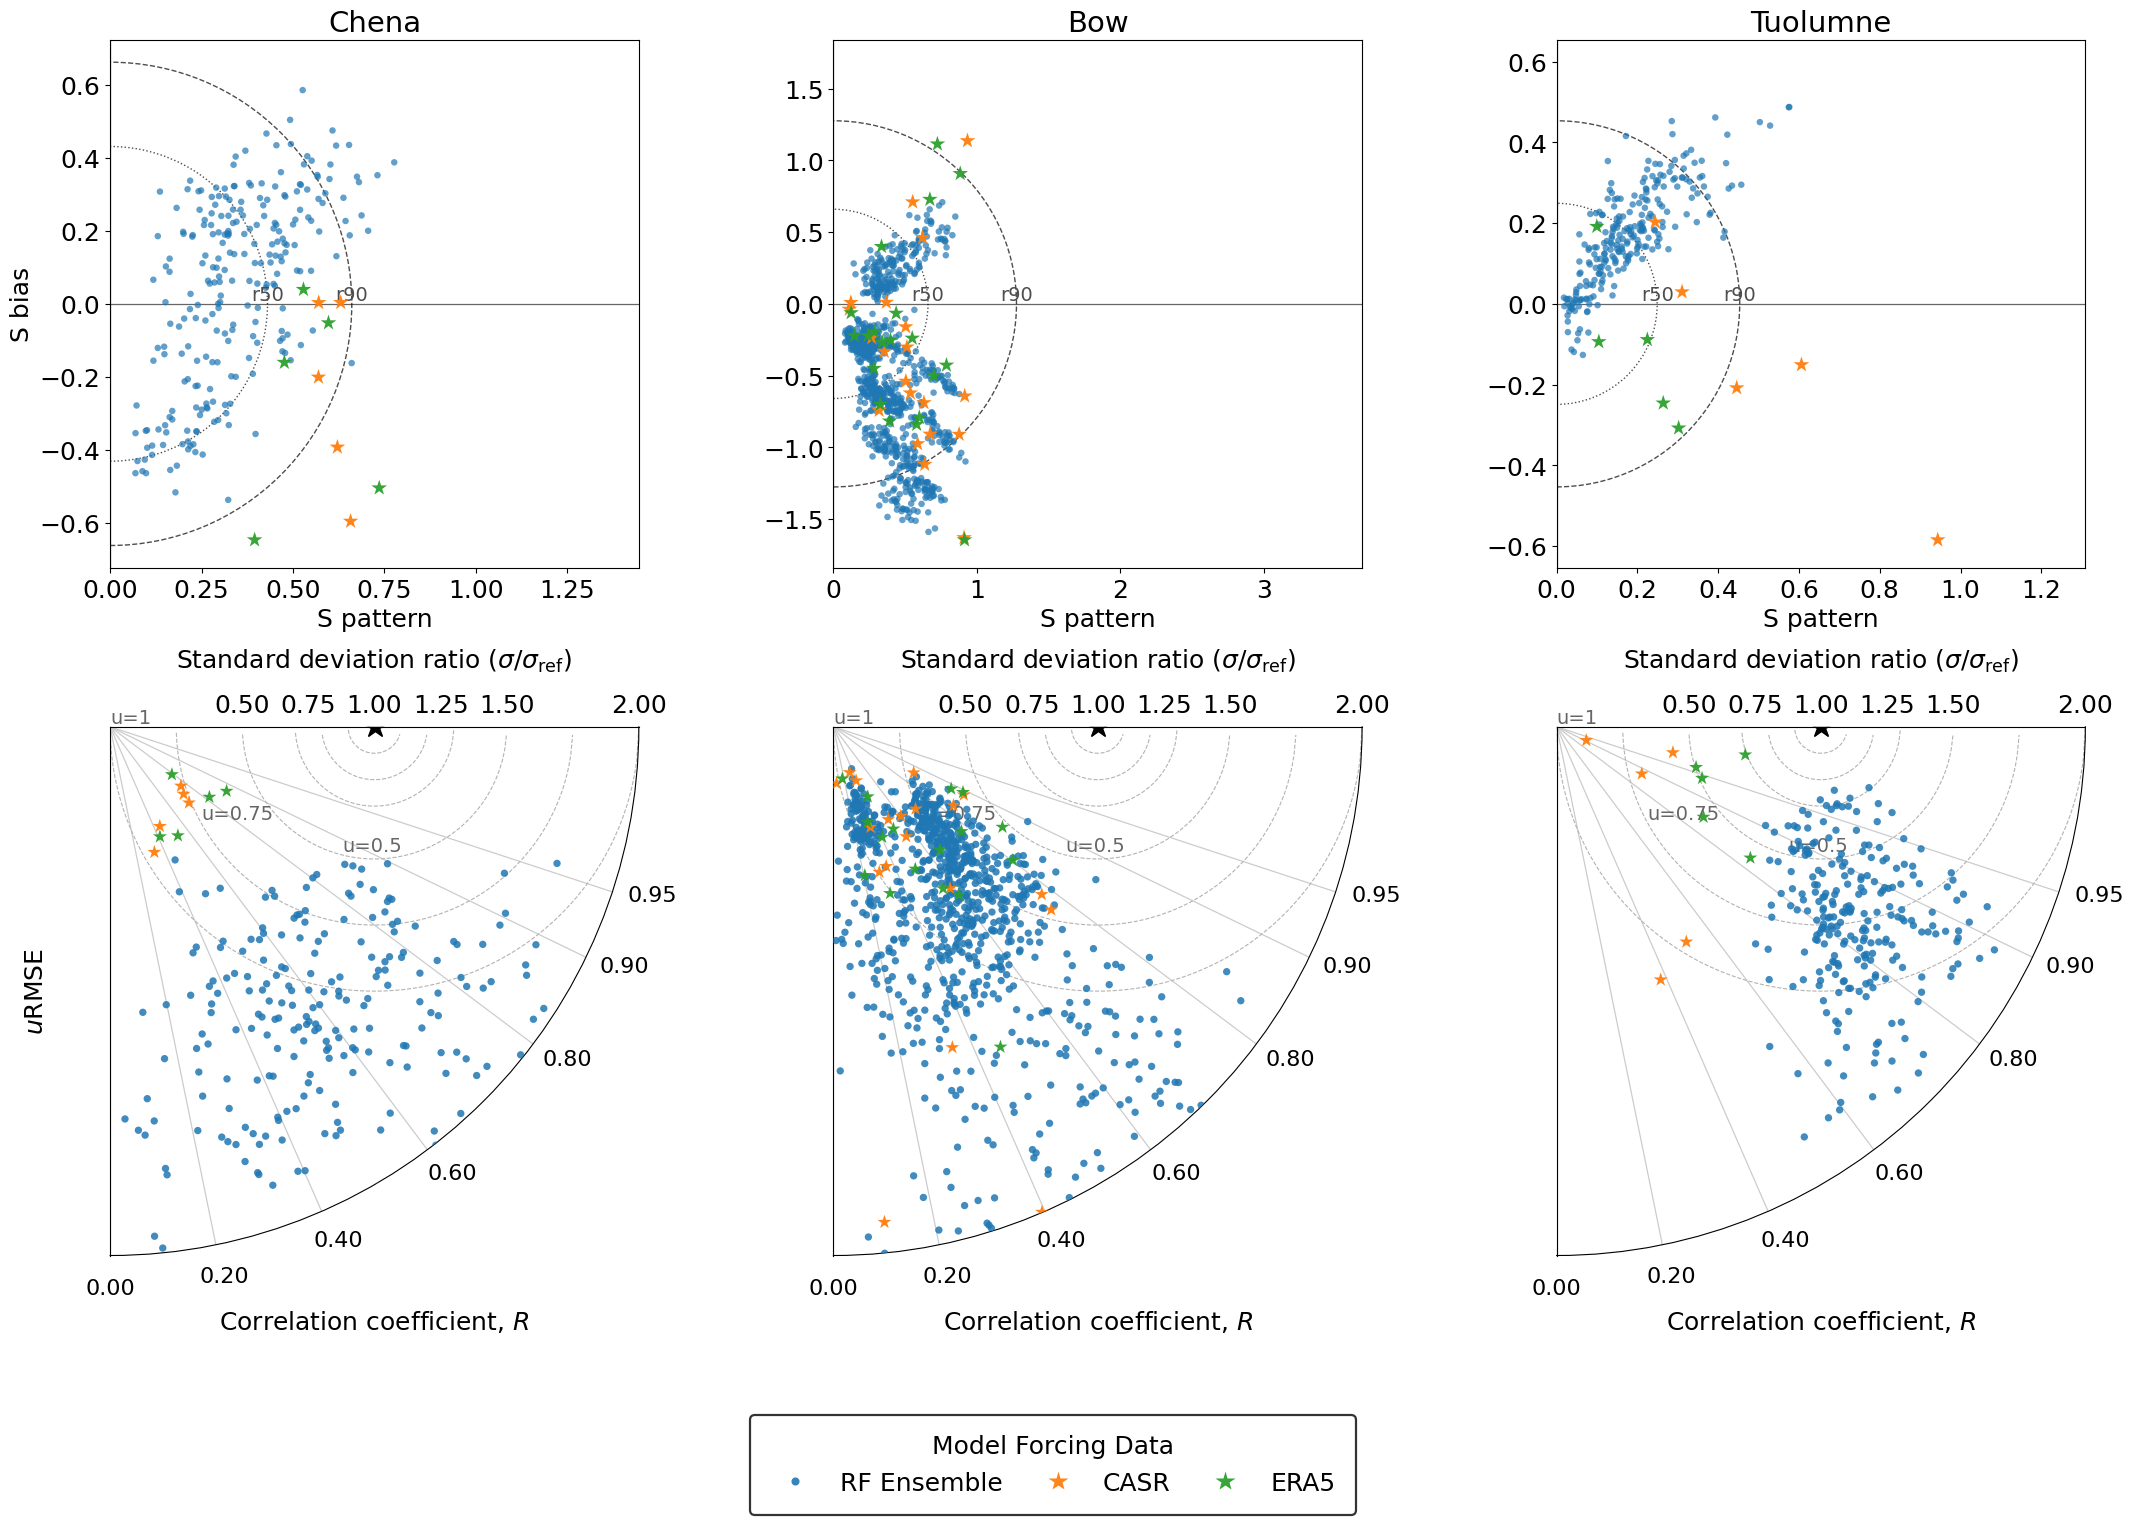

Saved /home/x-dcasson/GitRepos/gpep_to_summa_snakemake/workflow/notebooks/visualization/skill_outputs/combined_figures/target_heatmap_PLUS_taylor_3x2.pdf


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from numpy.linalg import LinAlgError

# ---------------- config ----------------
CATCHMENTS      = ["chena", "bow", "tuolumne"]
CSV_PATHS       = {cat: Path(f"./skill_outputs/skill_metrics_{cat}.csv") for cat in CATCHMENTS}
OUT_DIR         = Path("./skill_outputs/combined_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Target heatmap visual params
GRID_N          = 300
ALPHA_MAX       = 0.85
CUTOFF_REL      = 0.03
MIN_PTS         = 8
DRAW_RINGS      = True
SHOW_SPARSE_PTS = True
FIGSIZE         = (22.5, 16.0)   # 3 wide x 2 tall (tighter)

# ---- user-controlled axes ----
#TARGET_XLIM     = (0,3)
#TARGET_YLIM     = (-1.5, 1.5)
TAYLOR_RMAX     = 2

# Special markers for CASR and ERA5
STAR_SOURCES    = {"CASR", "ERA5"}
STAR_MARKER     = "*"
STAR_SIZE       = 140
STAR_ALPHA      = 0.95

# Taylor visual params
POINT_SIZE      = 28
ALPHA_PTS       = 0.85
R_TICKS         = [0.95, 0.9, 0.8, 0.6, 0.4, 0.2, 0.0]
URMSE_LEVELS    = [0.1, 0.2, 0.3, 0.5, 0.75, 1.0]

# --- Presentation font config ---
BASE_FONT = 18
LABEL_FONT = 18
TICK_FONT = 18
LEGEND_FONT = 22
LEGEND_TITLE_FONT = 18

plt.rcParams.update({
    'font.size': BASE_FONT,
    'axes.titlesize': LABEL_FONT,
    'axes.labelsize': LABEL_FONT,
    'xtick.labelsize': TICK_FONT,
    'ytick.labelsize': TICK_FONT,
    'legend.fontsize': LEGEND_FONT,
    'legend.title_fontsize': LEGEND_TITLE_FONT
})

def _fixed_hue_alpha_cmap(color, alpha_max=ALPHA_MAX, n=256):
    r, g, b = color[:3]
    alphas = np.linspace(0.0, alpha_max, n)
    table = np.column_stack([np.full(n, r), np.full(n, g), np.full(n, b), alphas])
    from matplotlib.colors import ListedColormap
    return ListedColormap(table)

def kde_on_grid(x, y, xlim, ylim, n=GRID_N):
    xs = np.linspace(xlim[0], xlim[1], n)
    ys = np.linspace(ylim[0], ylim[1], n)
    X, Y = np.meshgrid(xs, ys)
    XY = np.vstack([x, y])
    if np.linalg.matrix_rank(np.cov(XY)) < 2:
        eps = 1e-6 * max((xlim[1]-xlim[0]) + (ylim[1]-ylim[0]), 1.0)
        XY = XY + np.random.default_rng(0).normal(scale=eps, size=XY.shape)
    kde = gaussian_kde(XY)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    return X, Y, Z, float(Z.max())

def rgba_layer_from_density(Z, color, alpha_max=ALPHA_MAX, cutoff_rel=CUTOFF_REL):
    zmax = float(np.max(Z))
    if not np.isfinite(zmax) or zmax <= 0:
        return np.zeros(Z.shape + (4,), dtype=float), 0.0
    Zn = Z / zmax
    alpha = alpha_max * Zn
    alpha[Zn < cutoff_rel] = 0.0
    r, g, b = color[:3]
    rgba = np.empty(Z.shape + (4,), dtype=float)
    rgba[..., 0] = r; rgba[..., 1] = g; rgba[..., 2] = b; rgba[..., 3] = alpha
    return rgba, zmax

def _axis_limits_from_independent(df):
    # Calculate span needed independently for each catchment
    xmax = float(df["S_pattern"].max(skipna=True))
    yabs = float(np.nanmax(np.abs(df["S_bias"])))
    xmax = xmax if np.isfinite(xmax) else 0.0
    yabs = yabs if np.isfinite(yabs) else 0.0
    span_needed = max(xmax, 2.0 * yabs)
    if span_needed <= 0:
        span_needed = 1.0
    margin = 0.12 * span_needed
    L = span_needed + margin
    xlim = (0.0, L)
    ylim = (-L/2.0, L/2.0)
    return xlim, ylim

def _draw_taylor_axes(ax, rmax):
    ax.set_thetamin(0.0)
    ax.set_thetamax(90.0)
    ax.set_theta_direction(-1)
    ax.set_theta_zero_location("E")
    ax.set_rlim(0, rmax)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.grid(False)
    rticks = []
    for t in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5]:
        if t <= rmax * 1.02:
            rticks.append(t)
    if not rticks:
        rticks = [rmax]
    ax.set_rgrids(rticks, angle=135, fontsize=LABEL_FONT-2)
    for r in R_TICKS:
        if r < 0 or r > 1:
            continue
        theta = np.arccos(r)
        ax.plot([theta, theta], [0, rmax], color="0.8", lw=0.9, zorder=1)
        ax.text(theta, rmax * 1.08, f"{r:.2f}", ha="center", va="bottom", fontsize=LABEL_FONT-2)
    ax.set_title("")

def _draw_urmse_isolines(ax, rmax, levels=URMSE_LEVELS):
    sig = np.linspace(1e-3, rmax, 512)
    for c in levels:
        R = (1.0 + sig**2 - c**2) / (2.0 * sig)
        mask = (R >= 0.0) & (R <= 1.0)
        if not np.any(mask):
            continue
        theta = np.arccos(R[mask])
        ax.plot(theta, sig[mask], color="0.7", lw=0.8, ls="--", zorder=1)
        try:
            idx = np.argmax(mask)
            ax.text(theta[idx], sig[mask][idx], f"u={c:g}", fontsize=LABEL_FONT-4, color="0.4", ha="left", va="bottom")
        except Exception:
            pass

# ---------------- load & harmonize ----------------
dfs = []
for cat in CATCHMENTS:
    df = pd.read_csv(CSV_PATHS[cat])
    needed = {"Source", "GRU_ID", "member", "S_pattern", "S_bias", "S_total", "R", "sigma_ratio", "uRMSE_star"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{cat} CSV missing columns: {sorted(missing)}")
    df["S_pattern"] = pd.to_numeric(df["S_pattern"], errors="coerce").clip(lower=0)
    df["S_bias"]    = pd.to_numeric(df["S_bias"],    errors="coerce")
    df["S_total"]   = pd.to_numeric(df["S_total"],   errors="coerce")
    df["R"]         = pd.to_numeric(df["R"],         errors="coerce").clip(-1, 1)
    df["sigma_ratio"] = np.abs(pd.to_numeric(df["sigma_ratio"], errors="coerce"))
    dfs.append(df)

# Map sources to tab10, but do not force full palette for legend
sources_all = pd.concat([df["Source"] for df in dfs]).dropna().unique().tolist()
tab10 = plt.get_cmap("tab10")
color_map = {src: tab10(i % 10) for i, src in enumerate(sources_all)}

catch_titles = {"bow": "Bow", "chena": "Chena", "tuolumne": "Tuolumne"}

# --- Mapping for legend label rewriting ---
SOURCE_LEGEND_NAME_MAP = {
    "RF Static Dynamic": "RF Ensemble"
}

fig, axs = plt.subplots(2, 3, figsize=FIGSIZE, gridspec_kw={"height_ratios": [1, 1]})
plt.subplots_adjust(
    top=0.90,
    bottom=0.14,
    left=0.06,
    right=0.98,
    wspace=0.16,
    hspace=0.3   # slightly increased vertical distance between rows
)

src_handles = []
src_legend_markers = dict()
seen_sources = set()

# ---------------- row 1: Target scatter (no heatmap) ----------------
AX_X = []
AX_Y = []
for df in dfs:
    xlim, ylim = _axis_limits_from_independent(df)
    AX_X.append(xlim)
    AX_Y.append(ylim)

for j, (cat, df, ax) in enumerate(zip(CATCHMENTS, dfs, axs[0])):
    xlim = AX_X[j]
    ylim = AX_Y[j]
    ax.set_facecolor("white")
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.axhline(0, linewidth=0.9, color="k", alpha=0.6)
    ax.axvline(0, linewidth=0.9, color="k", alpha=0.6)
    ax.set_xlabel("S pattern", fontsize=LABEL_FONT)
    if j == 0:
        ax.set_ylabel("S bias", fontsize=LABEL_FONT)
    else:
        ax.set_ylabel("")

    ax.set_title(catch_titles.get(cat, cat), fontsize=LABEL_FONT+1)

    if DRAW_RINGS:
        st = df["S_total"].dropna().values
        if st.size:
            r50 = float(np.quantile(st, 0.50))
            r90 = float(np.quantile(st, 0.90))
            for rr, ls in [(r50, ":"), (r90, "--")]:
                ax.add_artist(plt.Circle((0, 0), rr, fill=False, linestyle=ls, color="0.3", linewidth=1.0))
            ax.text(r50, 0, "r50", ha="center", va="bottom", fontsize=LABEL_FONT-4, color="0.3")
            ax.text(r90, 0, "r90", ha="center", va="bottom", fontsize=LABEL_FONT-4, color="0.3")

    for src in df["Source"].dropna().unique():
        g = df[df["Source"] == src]
        x = g["S_pattern"].to_numpy()
        y = g["S_bias"].to_numpy()
        m = np.isfinite(x) & np.isfinite(y) & (x >= 0)
        x, y = x[m], y[m]
        if x.size == 0:
            continue
        color = color_map.get(src, (0.3, 0.3, 0.3))
        display_label = SOURCE_LEGEND_NAME_MAP.get(str(src), str(src))
        if str(src).upper() in STAR_SOURCES:
            # Plot with star
            ax.scatter(x, y, s=STAR_SIZE, marker=STAR_MARKER, color=color, alpha=STAR_ALPHA,
                       zorder=99, edgecolors="none")
            # Add to legend as a star if not already added
            if src not in seen_sources:
                src_handles.append(Line2D(
                    [0], [0],
                    marker=STAR_MARKER, linestyle="", color="none",
                    markerfacecolor=color, markeredgecolor="none",
                    markersize=np.sqrt(STAR_SIZE/np.pi)*2, lw=0,
                    alpha=STAR_ALPHA, label=display_label
                ))
                seen_sources.add(src)
                src_legend_markers[src] = dict(
                    marker=STAR_MARKER, linestyle="", color="none",
                    markerfacecolor=color, markeredgecolor="none",
                    markersize=np.sqrt(STAR_SIZE/np.pi)*2, lw=0,
                    alpha=STAR_ALPHA, label=display_label
                )
        else:
            ax.scatter(x, y, s=22, color=color, alpha=0.70, edgecolors="none", zorder=2)
            if src not in seen_sources:
                src_handles.append(Line2D(
                    [0], [0],
                    marker="o", color="none",
                    markerfacecolor=color, markeredgecolor="none",
                    markersize=np.sqrt(22/np.pi)*2, lw=0,
                    alpha=0.9, label=display_label
                ))
                seen_sources.add(src)
                src_legend_markers[src] = dict(
                    marker="o", color="none",
                    markerfacecolor=color, markeredgecolor="none",
                    markersize=np.sqrt(22/np.pi)*2, lw=0,
                    alpha=0.9, label=display_label
                )

def kde_on_polar_grid(theta_vals, rho_vals, thetalim, rmax, n_theta=220, n_r=180):
    ths = np.linspace(thetalim[0], thetalim[1], n_theta)
    rhs = np.linspace(0.0, rmax, n_r)
    TH, RH = np.meshgrid(ths, rhs)
    T = np.vstack([theta_vals, rho_vals])
    if np.linalg.matrix_rank(np.cov(T)) < 2:
        eps = 1e-6 * max((thetalim[1]-thetalim[0]) + rmax, 1.0)
        T = T + np.random.default_rng(0).normal(scale=eps, size=T.shape)
    kde = gaussian_kde(T)
    Z = kde(np.vstack([TH.ravel(), RH.ravel()])).reshape(TH.shape)
    return TH, RH, Z

# --- Taylor plot label strings ---
TAYLOR_TOP_LABEL   = r"Standard deviation ratio ($\sigma / \sigma_{\mathrm{ref}}$)"
TAYLOR_URMSE_LABEL = r"$u\mathrm{RMSE}$"
TAYLOR_CORR_LABEL  = r"Correlation coefficient, $R$"

# ---------------- row 2: Taylor plots ----------------
for j, (cat, df, ax) in enumerate(zip(CATCHMENTS, dfs, axs[1])):
    # Set Taylor Rmax independently per catchment if not set globally
    if TAYLOR_RMAX is not None:
        rmax = float(TAYLOR_RMAX)
    else:
        rmax = float(np.nanmax(df["sigma_ratio"])) if np.isfinite(df["sigma_ratio"]).any() else 1.0
        rmax = 1.05 * rmax if rmax > 0 else 1.0

    pax = ax.figure.add_subplot(ax.get_subplotspec(), projection="polar")
    ax.axis("off")
    _draw_taylor_axes(pax, rmax)
    _draw_urmse_isolines(pax, rmax, levels=URMSE_LEVELS)
    # Reference point (σ_ref=1, R=1)
    pax.plot([0], [1], marker="*", markersize=16, color="k", zorder=6)

    for src in df["Source"].dropna().unique():
        g = df[df["Source"] == src]
        theta = np.arccos(g["R"].to_numpy().clip(-1, 1))
        rho   = np.abs(g["sigma_ratio"].to_numpy())
        m = np.isfinite(theta) & np.isfinite(rho) & (theta >= 0) & (theta <= np.pi/2) & (rho >= 0)
        theta, rho = theta[m], rho[m]
        if theta.size == 0:
            continue
        col = color_map.get(src, (0.3, 0.3, 0.3))
        display_label = SOURCE_LEGEND_NAME_MAP.get(str(src), str(src))
        if str(src).upper() in STAR_SOURCES:
            # Plot with star
            pax.scatter(
                theta, rho,
                s=STAR_SIZE*0.8, marker=STAR_MARKER,
                color=col, alpha=STAR_ALPHA,
                zorder=99, edgecolors="none",
                label=display_label
            )
            # Add to legend only if not yet seen
            if src not in src_legend_markers:
                src_handles.append(Line2D(
                    [0], [0],
                    marker=STAR_MARKER, linestyle="", color="none",
                    markerfacecolor=col, markeredgecolor="none",
                    markersize=np.sqrt(STAR_SIZE*0.8/np.pi)*2, lw=0,
                    alpha=STAR_ALPHA, label=display_label
                ))
                src_legend_markers[src] = dict(
                    marker=STAR_MARKER, linestyle="", color="none",
                    markerfacecolor=col, markeredgecolor="none",
                    markersize=np.sqrt(STAR_SIZE*0.8/np.pi)*2, lw=0,
                    alpha=STAR_ALPHA, label=display_label
                )
        else:
            pax.scatter(
                theta, rho,
                s=POINT_SIZE, alpha=ALPHA_PTS,
                edgecolors="none", color=col,
                label=display_label, zorder=10
            )
            if src not in src_legend_markers:
                src_handles.append(Line2D(
                    [0], [0],
                    marker="o", color="none",
                    markerfacecolor=col, markeredgecolor="none",
                    markersize=np.sqrt(POINT_SIZE/np.pi)*2, lw=0,
                    alpha=0.9, label=display_label
                ))
                src_legend_markers[src] = dict(
                    marker="o", color="none",
                    markerfacecolor=col, markeredgecolor="none",
                    markersize=np.sqrt(POINT_SIZE/np.pi)*2, lw=0,
                    alpha=0.9, label=display_label
                )

    # --- Taylor diagram labels on every subplot ---
    # Top: standard deviation ratio
    pax.text(
        0.5, 1.10,
        TAYLOR_TOP_LABEL,
        transform=pax.transAxes,
        ha="center", va="bottom",
        fontsize=LABEL_FONT
    )

    # Left side: uRMSE (vertical)
    if j == 0:
        pax.text(
            -0.14, 0.5,
            TAYLOR_URMSE_LABEL,
            transform=pax.transAxes,
            ha="center", va="center",
            rotation=90,
            fontsize=LABEL_FONT
        )

    # Bottom: correlation coefficient
    pax.text(
        0.5, -0.10,
        TAYLOR_CORR_LABEL,
        transform=pax.transAxes,
        ha="center", va="top",
        fontsize=LABEL_FONT
    )

# Top-row catchment labels only
for j, (cat, ax) in enumerate(zip(CATCHMENTS, axs[0])):
    ax.set_title(catch_titles.get(cat, cat), fontsize=LABEL_FONT+3)

# ---------------- shared legend & title ----------------
unique_leg_handles = []
seen_leg_labels = set()
for handle in src_handles:
    this_label = handle.get_label()
    if this_label not in seen_leg_labels:
        unique_leg_handles.append(handle)
        seen_leg_labels.add(this_label)

if unique_leg_handles:
    ncols = min(len(unique_leg_handles), 6)
    fig.legend(
        handles=unique_leg_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=ncols,
        frameon=False,
        handlelength=2,
        columnspacing=1.2,
        borderpad=0.8,
        markerscale=1.1,
        fontsize=LEGEND_FONT,
    )

out_png = OUT_DIR / "target_heatmap_PLUS_taylor_3x2.pdf"
fig.savefig(out_png, bbox_inches="tight", dpi=300)
print(f"Output to {out_png}")
plt.show()
plt.close(fig)

print(f"Saved {out_png.resolve()}")